# Standardized response mean (SRM) - Sensitivity to change
This notebook contains the analyses related to estimating the sensitivity to change of the considered variables of interest, including measurements and clinical scores.

## Modules

In [ ]:
import json
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import gridspec
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
from scipy.stats import spearmanr

from longitudinal_arm_swing.constants import *
from longitudinal_arm_swing.utils import strip_med_suffix_id, make_json_serializable, calculate_ci

pd.set_option('display.max_columns', 500)

## Constants

In [ ]:
filter_type = 'filtered'
signal_or_measurements = 'signal'
l1tf_phased = False
interpolated = True
save_plots = True

measures = ['median', '95p', 'median_cov']
segment_lengths = ['0_20', '20_inf']
weight_types = ['ipcw_raw', 'ipcw_stab']

path_measures = BASE_PATH / 'measures' / f'{filter_type}_gait'
path_survival_probabilities = BASE_PATH / 'measures' / 'filtered_gait'
path_figures_paper = r'C:\Users\z665206\Documents\PhD\docs\papers\ppp\paper\tex\imgs'

pd_med_id_filename = 'pd_med_ids.txt'
pd_no_med_id_filename = 'pd_no_med_ids.txt'
ids_remaining_after_exclusions_filename = 'ids_remaining_after_exclusions.json'
aff_side_ids_filename = 'affected_side_ids.json'

start_week = 2
start_weeks = [2, 4, 6]
final_week_1y = 50
final_week_2y = 100
all_weeks_1y = np.arange(start_week, final_week_1y + 1, 2)
all_weeks_2y = np.arange(start_week, final_week_2y + 1, 2)
final_weeks_1y = np.arange(start_week + 2, final_week_1y + 1, 2)
final_weeks_2y = np.arange(start_week + 2, final_week_2y + 1, 2)

clinical_score = 'hypokinesia'
updrs_score_map = [
    ('updrs_3_hand_movement_on_ws', 'Up3OnHaMoYesDev', 'Up3OnHaMoYesDev'),
    ('updrs_3_hand_movement_off_ws', 'Up3OfHaMoYesDev', 'Up3OfHaMoYesDev'),
    ('updrs_3_pro_sup_on_ws', 'Up3OnProSYesDev', 'Up3OnProSYesDev'),
    ('updrs_3_pro_sup_off_ws', 'Up3OfProSYesDev', 'Up3OfProSYesDev'),
    ('updrs_3_finger_tapping_on_ws', 'Up3OnFiTaYesDev', 'Up3OnFiTaYesDev'),
    ('updrs_3_finger_tapping_off_ws', 'Up3OfFiTaYesDev', 'Up3OfFiTaYesDev'),
    ('updrs_3_toe_tapping_on_ws', 'Up3OnToTaYesDev', 'Up3OnToTaYesDev'),
    ('updrs_3_toe_tapping_off_ws', 'Up3OfToTaYesDev', 'Up3OfToTaYesDev'),
    ('updrs_3_leg_agility_on_ws', 'Up3OnLAgiYesDev', 'Up3OnLAgiYesDev'),
    ('updrs_3_leg_agility_off_ws', 'Up3OfLAgiYesDev', 'Up3OfLAgiYesDev'),
    ('updrs_3_rigidity_lower_extremity_on_ws', 'Up3OnRigLle', 'Up3OnRigRle'),
    ('updrs_3_rigidity_lower_extremity_off_ws', 'Up3OfRigLle', 'Up3OfRigRle'),
    ('updrs_3_rigidity_upper_extremity_on_ws', 'Up3OnRigLue', 'Up3OnRigRue'),
    ('updrs_3_rigidity_upper_extremity_off_ws', 'Up3OfRigLue', 'Up3OfRigRue'),
    ('updrs_3_off_gait', 'Up3OfGait', 'Up3OfGait'),
    ('updrs_3_on_gait', 'Up3OnGait', 'Up3OnGait'),
]

updrs_scores = ['updrs_1_total', 'updrs_2_total', 'Updrs2It12', 'Up3OfGait', 'Up3OnGait'] + [
                f'updrs_3_{score}' for score in [
                    'off_total', 'on_total', 'hypokinesia_off_ws', 'hypokinesia_on_ws', 
                    'bradykinesia_off_ws', 'bradykinesia_on_ws', 'rigidity_off_ws', 
                    'rigidity_on_ws'
                ]] + [updrs_score_map[i][0] for i in range(len(updrs_score_map))]

## Functions

In [ ]:
def bootstrap_and_compute_sensitivity_to_change(values, B=1000, weights=[], seed=None):
    N = len(values)
    if N == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        
    rng = np.random.default_rng(seed)
    boot_stats = []

    for _ in range(B):
        sampled_indices = rng.integers(low=0, high=N, size=N)
        sampled_values = values[sampled_indices]

        if len(weights) == 0:
            mean_change = np.mean(sampled_values)
            std_change = np.std(sampled_values, ddof=1)
            stat = mean_change / std_change if std_change != 0 else np.nan
            boot_stats.append(stat)

        else:
            sampled_weights = weights[sampled_indices]
            weight_sum = np.nansum(sampled_weights)
            if weight_sum == 0:
                boot_stats.append(np.nan)
                continue
            
            mean_change = np.nansum(sampled_values * sampled_weights) / weight_sum
            var_change = np.nansum(((sampled_values - mean_change) ** 2) * sampled_weights) / weight_sum
            std_change = np.sqrt(var_change)
            stat = mean_change / std_change if std_change != 0 else np.nan
            boot_stats.append(stat)

    # Point estimate
    if len(weights) == 0:
        mean_change = np.mean(values)
        std_change = np.std(values, ddof=1)
        point_est = mean_change / std_change if std_change != 0 else np.nan
        desc1, desc2 = mean_change, std_change
    else:
        weight_sum = np.nansum(weights)

        mean_change = np.nansum(values * weights) / weight_sum
        var_change = np.nansum(((values - mean_change) ** 2) * weights) / weight_sum
        std_change = np.sqrt(var_change)
        point_est = mean_change / std_change if std_change != 0 else np.nan
        desc1, desc2 = mean_change, std_change

    boot_stats = np.array(boot_stats)
    ci_lower, ci_upper = np.nanpercentile(boot_stats, [2.5, 97.5])
    p_val = 2 * min(np.mean(boot_stats <= 0), np.mean(boot_stats >= 0))

    return desc1, desc2, point_est, ci_lower, ci_upper, p_val

def lighten_color(color, amount=0.5):
    return tuple(1 - (1 - x) * (1 - amount) for x in color)

def get_color(side, status):
    base_color = COLOR_GROUP_1 if side == 'mas' else (COLOR_GROUP_2 if side == 'las' else COLOR_GROUP_NEUTRAL)
    return base_color if status in ['Filtered', 'Weighted', 'controls'] else lighten_color(base_color, 0.5)

# Load

In [ ]:
prepared_data = {}
for group in ['pd', 'controls']:
    prepared_data[group] = {}
    for segment_length in segment_lengths:
        prepared_data[group][segment_length] = {
            'measurements': {},
            'signal': {},
        }
        for measure in measures:
            measure_extended = f'{measure}_range_of_motion'
            if group == 'pd':
                if l1tf_phased:
                    prepared_data[group][segment_length]['signal'][measure] = pd.DataFrame()
                    for file in os.listdir(path_measures / segment_length / 'lambda_fit_by_duration'):
                        if file.startswith(f'{group}_signal_interp_{measure_extended}_'):
                            week_nr = int(file.split('_')[-1].split('.')[0].replace('w', ''))
                            if week_nr not in prepared_data[group][segment_length]['signal']:
                                df_week = pd.read_csv(path_measures / segment_length /'lambda_fit_by_duration', file)
                                prepared_data[group][segment_length]['signal'][measure][f'week{week_nr}'] = df_week[f'week{week_nr}']

                    med_data = pd.read_csv(path_measures / segment_length / f'{group}_med_measure_{measure_extended}.csv')
                    no_med_data = pd.read_csv(path_measures / segment_length / f'{group}_no_med_measure_{measure_extended}.csv')
                    df_pd_tmp = pd.concat([med_data, no_med_data], ignore_index=True)
                    df_pd_tmp.columns = [f'week{week}' for week in df_pd_tmp.columns]

                    for week in [2, 4, 6]:
                        prepared_data[group][segment_length]['signal'][measure][f'week{week}'] = df_pd_tmp[f'week{week}']
                else:
                    med_data = pd.read_csv(path_measures / segment_length / f'{group}_med_measure_{measure_extended}.csv')
                    no_med_data = pd.read_csv(path_measures / segment_length / '{group}_no_med_measure_{measure_extended}.csv')
                    prepared_data[group][segment_length]['measurements'][measure] = pd.concat([med_data, no_med_data], ignore_index=True)
            else:
                prepared_data[group][segment_length]['measurements'][measure] = pd.read_csv(path_measures / segment_length / f'{group}_measure_{measure_extended}.csv')

            if not l1tf_phased:
                prepared_data[group][segment_length]['measurements'][measure].columns = [f'week{week}' for week in prepared_data[group][segment_length]['measurements'][measure].columns]

            if interpolated and not l1tf_phased:
                prepared_data[group][segment_length]['signal'][measure] = pd.read_csv(path_measures / segment_length / f'{group}_signal_interp_{measure_extended}.csv')
            elif not l1tf_phased:
                prepared_data[group][segment_length]['signal'][measure] = pd.read_csv(path_measures / segment_length / f'{group}_signal_{measure_extended}.csv')

df_measures_inclusion = pd.read_parquet(BASE_PATH / 'measures' / 'digital_measures.parquet')
df_clinical = pd.read_parquet(PATH_CLINICAL_DATA / 'clinical_data.parquet')

with open(path_measures / '20_inf' / 'pd_med_ids.txt', 'r') as f:
    pd_med_ids = f.read().splitlines()

with open(path_measures / '20_inf' / 'pd_no_med_ids.txt', 'r') as f:
    pd_no_med_ids = f.read().splitlines()

pd_no_med_ids = [c for c in pd_no_med_ids if c != 'POMUEE612759679A830D']
with open(path_measures / '20_inf' / 'pd_no_med_ids.txt', 'w') as f:
    f.write('\n'.join(pd_no_med_ids))

with open(path_measures / '20_inf' / 'controls_ids.txt', 'r') as f:
    controls_ids = f.read().splitlines()

with open(PATH_IDS / ids_remaining_after_exclusions_filename, 'r') as f:
    ids_remaining_after_exclusions = json.load(f)

with open(PATH_IDS / aff_side_ids_filename, 'r') as f:
    aff_side_ids = json.load(f)

with open(PATH_IDS / 'med_info_ids.json', 'r') as f:
    med_info_ids = json.load(f)

with open(PATH_IDS / 'excluded_ids_by_category.json', 'r') as f:
    excluded_ids_by_category = json.load(f)

with open(PATH_IDS / 'ids_late_visit_3.txt', 'r') as f:
    ids_late_visit_3 = f.read().splitlines()

survival_probabilities = {}
for med_state, min_week in zip(['med', 'no_med'], [50, 2]):
    survival_probabilities[med_state] = {}
    for measure in measures:
        df_surv_prob = pd.read_csv(path_survival_probabilities / f'survival_probabilities_{med_state}.csv')
        survival_probabilities[med_state][measure] = {
            'unstabilized': (
                df_surv_prob
                .pivot(index='id', columns='week', values='p_uncensored_given_X')
                .reset_index()
                .rename_axis(None, axis=1)
                .rename(columns={col: f'week{int(col)}' for col in df_surv_prob['week'].unique()})
            ),
            'stabilized': (
                df_surv_prob
                .pivot(index='id', columns='week', values='ipcw_stabilized')
                .reset_index()
                .rename_axis(None, axis=1)
                .rename(columns={col: f'week{col}' for col in range(min_week, 101, 2)})
            )
        }

start_med_week_dict = {
    'ppp': pd.read_csv(PATH_CLINICAL_DATA / 'ppp' / PPP_START_MED_FILENAME),
    'denovo': pd.read_csv(PATH_CLINICAL_DATA / 'denovo' / DENOVO_START_MED_WEEK_FILENAME)
}

# Prepare data

In [12]:
for new_col, left_col, right_col in updrs_score_map:
    df_clinical.loc[df_clinical['WatchSide'] == 'left', new_col] = df_clinical.loc[df_clinical['WatchSide'] == 'left', left_col]
    df_clinical.loc[df_clinical['WatchSide'] == 'right', new_col] = df_clinical.loc[df_clinical['WatchSide'] == 'right', right_col]

In [ ]:
pd_ids = pd_med_ids + pd_no_med_ids

idx_med_ids = [pd_ids.index(x) for x in pd_med_ids if x in pd_ids]
idx_no_med_ids = [len(pd_med_ids) + pd_no_med_ids.index(x) for x in pd_no_med_ids if x in pd_ids]

ids_2y = ids_remaining_after_exclusions['ppp']['srm_2y'] + ids_remaining_after_exclusions['denovo']['srm_2y']
ids_y1 = ids_remaining_after_exclusions['ppp']['srm_1y'] + ids_remaining_after_exclusions['denovo']['srm_1y']

get_week_ppp = lambda id: start_med_week_dict['ppp'].loc[start_med_week_dict['ppp']['ID'] == id, 'StartWeek'].values[0]
get_week_denovo = lambda id: start_med_week_dict['denovo'].loc[start_med_week_dict['denovo']['ID'] == id, 'StartWeek'].values[0]

start_med_ids = [strip_med_suffix_id(id) for id in ids_remaining_after_exclusions['ppp']['l1tf_start_med'] if get_week_ppp(strip_med_suffix_id(id)) < 100] + \
    [strip_med_suffix_id(id) for id in ids_remaining_after_exclusions['denovo']['l1tf_start_med'] if get_week_denovo(strip_med_suffix_id(id)) < 100]

start_med_early_ids = [strip_med_suffix_id(id) for id in ids_remaining_after_exclusions['ppp']['l1tf_start_med'] if get_week_ppp(strip_med_suffix_id(id)) < 8] + \
    [strip_med_suffix_id(id) for id in ids_remaining_after_exclusions['denovo']['l1tf_start_med'] if get_week_denovo(strip_med_suffix_id(id)) < 8]

delta_scores = {}
srm_ids_per_week = {}

for segment_length in segment_lengths:
    delta_scores[segment_length] = {}
    srm_ids_per_week[segment_length] = {}

    if not l1tf_phased:
        ids_valid_start_week = [
            pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                prepared_data['pd'][segment_length][signal_or_measurements]['median']['week2'].notna()
            ].index 
        ]
        ids_valid_final_week_y1 = [
            pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                prepared_data['pd'][segment_length][signal_or_measurements]['median']['week50'].notna()
            ].index 
        ]
        ids_valid_final_week_y2 = [
            pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                prepared_data['pd'][segment_length][signal_or_measurements]['median']['week100'].notna()
            ].index 
        ]

    for side in ['mas', 'las']:
        relevant_aff_side_ids = aff_side_ids['ppp'][side] + aff_side_ids['denovo'][side]
        for med_status, ids_status in zip(['med', 'no_med'], [pd_med_ids, pd_no_med_ids]):
            key_prefix = f'pd_{side}_{med_status}'
            delta_scores[segment_length][key_prefix] = {}
            srm_ids_per_week[segment_length][key_prefix] = {}
            
            ids_visits_12 = df_clinical.loc[df_clinical['visit'].isin([1, 2])]['id'].value_counts().loc[lambda x: x == 2].index.tolist()
            ids_visits_13 = df_clinical.loc[df_clinical['visit'].isin([1, 3])]['id'].value_counts().loc[lambda x: x == 2].index.tolist()

            # Also check whether participant is included in srm analysis (has valid arm swing weeks in final weeks)
            ids_visits_12 = [id for id in ids_visits_12 if id in ids_valid_final_week_y1 and id in ids_y1]
            ids_visits_13 = [id for id in ids_visits_13 if id in ids_valid_final_week_y2 and id in ids_2y]

            df_clinical_filtered = df_clinical[(df_clinical['id'].isin(ids_status)) & (df_clinical['id'].isin(relevant_aff_side_ids)) & (df_clinical['id'].isin(ids_valid_start_week)) & (~df_clinical['id'].isin(ids_late_visit_3))]
            df_clinical_filtered = df_clinical_filtered.drop_duplicates(subset=['id', 'visit'], keep='first')  # Due to starting medication participants

            for score in updrs_scores:
                df_v1 = df_clinical_filtered[df_clinical_filtered['visit'] == 1][['id', score]].rename(columns={score: f'{score}_v1'})
                df_v2 = df_clinical_filtered[df_clinical_filtered['visit'] == 2][['id', score]].rename(columns={score: f'{score}_v2'})
                df_v3 = df_clinical_filtered[df_clinical_filtered['visit'] == 3][['id', score]].rename(columns={score: f'{score}_v3'})

                # Merge for 1y (visit 2)
                df_12 = pd.merge(df_v1, df_v2, on='id')
                df_12['delta'] = df_12[f'{score}_v2'] - df_12[f'{score}_v1']
                df_12 = df_12[df_12['id'].isin(ids_visits_12) & df_12['delta'].notna()]

                # Merge for 2y (visit 3)
                df_13 = pd.merge(df_v1, df_v3, on='id')
                df_13['delta'] = df_13[f'{score}_v3'] - df_13[f'{score}_v1']
                df_13 = df_13[df_13['id'].isin(ids_visits_13) & df_13['delta'].notna()]

                delta_scores[segment_length][key_prefix][score] = {
                    '1y': {
                        'ids': df_12['id'].tolist(),
                        'unweighted': df_12['delta'].tolist()
                    },
                    '2y': {
                        'ids': df_13['id'].tolist(),
                        'unweighted': df_13['delta'].tolist()
                    }
                }

            for measure in measures:
                delta_scores[segment_length][key_prefix][measure] = {}
                df_measure = prepared_data['pd'][segment_length][signal_or_measurements][measure]

                if df_measure.shape[0] == 511:
                    df_measure = df_measure.drop(509)

                df_measure['id'] = pd_ids
                    
                df_measure_filtered = df_measure[
                    (df_measure['id'].isin(ids_status)) & 
                    (df_measure['id'].isin(relevant_aff_side_ids)) & 
                    (df_measure['id'].isin(ids_valid_start_week)) &
                    (df_measure.index.isin(idx_med_ids if med_status == 'med' else idx_no_med_ids))
                ]            

                df_surv_uncensored_prob = survival_probabilities[med_status][measure]['unstabilized'].copy()
                df_surv_stabilized = survival_probabilities[med_status][measure]['stabilized'].copy()

                surv_ids = df_surv_stabilized['id'].values.tolist()

                ids_final_week_measure = [pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                    (prepared_data['pd'][segment_length][signal_or_measurements]['median'][f'week{final_week_2y}'].notna()) &
                    (prepared_data['pd'][segment_length][signal_or_measurements]['median'][f'week{start_week}'].notna())
                ].index if pd_ids[x] in df_measure_filtered['id'].values]

                static_ids = [id for id in ids_final_week_measure if id in ids_2y]

                ids_week_measure = [
                    pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                        prepared_data['pd'][segment_length][signal_or_measurements]['median'][f'week{start_week}'].notna()
                    ].index if pd_ids[x] in df_measure_filtered['id'].values
                ]
                srm_ids_per_week[segment_length][key_prefix][2] = [id for id in ids_week_measure if id not in start_med_early_ids]

                for week in final_weeks_2y:
                    ids_week_measure = [pd_ids[x] for x in prepared_data['pd'][segment_length][signal_or_measurements]['median'].loc[
                        (prepared_data['pd'][segment_length][signal_or_measurements]['median'][f'week{week}'].notna()) &
                        (prepared_data['pd'][segment_length][signal_or_measurements]['median'][f'week{start_week}'].notna())
                    ].index if pd_ids[x] in df_measure_filtered['id'].values]

                    srm_ids_per_week[segment_length][key_prefix][int(week)] = [id for id in ids_week_measure if id not in start_med_early_ids]

                    df_dynamic = df_measure_filtered.loc[
                        (df_measure_filtered['id'].isin(ids_week_measure)) & 
                        (~df_measure_filtered['id'].isin(start_med_early_ids)) &
                        (df_measure_filtered['id'].isin(surv_ids))
                    ]
                    ids_dynamic = df_dynamic['id'].values.tolist()
                    start_week_vals_dynamic = df_dynamic[f'week{start_week}'].values
                    current_week_vals_dynamic = df_dynamic[f'week{week}'].values

                    df_static = df_measure_filtered.loc[
                        (df_measure_filtered['id'].isin(ids_week_measure)) & 
                        (~df_measure_filtered['id'].isin(start_med_ids)) &
                        (df_measure_filtered['id'].isin(surv_ids)) &
                        (df_measure_filtered['id'].isin(static_ids))
                    ]
                    ids_static = df_static['id'].values.tolist()
                    start_week_vals_static = df_static[f'week{start_week}'].values 
                    current_week_vals_static = df_static[f'week{week}'].values
                    
                    delta_scores[segment_length][key_prefix][measure][f'dynamic_{week}'] = {
                        'ids': ids_dynamic,
                        'unweighted': current_week_vals_dynamic - start_week_vals_dynamic
                    }
                    delta_scores[segment_length][key_prefix][measure][f'static_{week}'] = {
                        'ids': ids_static,
                        'unweighted': current_week_vals_static - start_week_vals_static
                    }

                    if week >= start_week:
                        for setup, setup_ids in zip(['static', 'dynamic'], [ids_static, ids_dynamic]):
                            for weight_type in weight_types:
                                df_setup = df_surv_stabilized if weight_type == 'ipcw_stab' else df_surv_uncensored_prob
                                if med_status == 'med' and week < 50:
                                    delta_scores[segment_length][key_prefix][measure][f'{setup}_{week}'][weight_type] = np.ones(len(setup_ids))
                                else:
                                    df_p_setup = df_setup.loc[(df_setup['id'].isin(ids_week_measure)) & ~(df_setup['id'].isin(start_med_early_ids)) & (df_setup['id'].isin(setup_ids))].copy()

                                    if df_setup.empty:
                                        delta_scores[segment_length][key_prefix][measure][f'{setup}_{week}'][weight_type] = np.ones(len(setup_ids))
                                        continue
                                    
                                    ids_surv_setup = df_p_setup['id'].values.tolist()

                                    if weight_type == 'ipcw_raw':
                                        weights_week_setup = 1 / df_p_setup[f'week{week}'].values  # inverse of probability
                                    else:
                                        weights_week_setup = df_p_setup[f'week{week}'].values  # stabilized weights

                                    # Map weights onto ids
                                    weights_mapping = dict(zip(ids_surv_setup, weights_week_setup))
                                    weights_week = np.array([weights_mapping.get(id, 1.0) for id in setup_ids])

                                    delta_scores[segment_length][key_prefix][measure][f'{setup}_{week}'][weight_type] = weights_week
                            
    if not l1tf_phased:
        key_prefix = 'controls'

        delta_scores[segment_length][key_prefix] = {}
        srm_ids_per_week[segment_length][key_prefix] = {}
        ids_both_visits = df_clinical.loc[df_clinical['visit'].isin([1, 2])]['id'].value_counts().loc[lambda x: x == 2].index.tolist()
        df_clinical_filtered = df_clinical[(df_clinical['dataset'] == 'controls') & (df_clinical['id'].isin(ids_both_visits))]

        final_week_ids = [controls_ids[x] for x in prepared_data['controls'][segment_length][signal_or_measurements]['median'].loc[
            prepared_data['controls'][segment_length][signal_or_measurements]['median'][f'week{final_week_1y}'].notna()
        ].index]

        for measure in measures:
            delta_scores[segment_length][key_prefix][measure] = {}
            df_measure = prepared_data['controls'][segment_length][signal_or_measurements][measure]
            df_measure['id'] = controls_ids

            ids_week_measure = [
                controls_ids[x] for x in prepared_data['controls'][segment_length][signal_or_measurements]['median'].loc[
                    prepared_data['controls'][segment_length][signal_or_measurements]['median'][f'week{start_week}'].notna()
                ].index
            ]
            srm_ids_per_week[segment_length][key_prefix][start_week] = ids_week_measure
            
            for week in final_weeks_1y:
                # Check where both values are not NaN
                ids_week_measure = [controls_ids[x] for x in prepared_data['controls'][segment_length][signal_or_measurements]['median'].loc[
                    (prepared_data['controls'][segment_length][signal_or_measurements]['median'][f'week{week}'].notna()) &
                    (prepared_data['controls'][segment_length][signal_or_measurements]['median'][f'week{start_week}'].notna())
                ].index]
                srm_ids_per_week[segment_length][key_prefix][int(week)] = ids_week_measure

                delta_dynamic = df_measure[f'week{week}'].values - df_measure[f'week{start_week}'].values
                delta_scores[segment_length][key_prefix][measure][f'dynamic_{week}'] = {
                    'ids': ids_week_measure,
                    'unweighted': delta_dynamic
                }

                static_ids = [id for id in final_week_ids if id in ids_week_measure]
                delta_static = df_measure.loc[df_measure['id'].isin(final_week_ids), f'week{week}'].values - df_measure.loc[df_measure['id'].isin(final_week_ids), f'week{start_week}'].values
                delta_scores[segment_length][key_prefix][measure][f'static_{week}'] = {
                    'ids': static_ids,
                    'unweighted': delta_static
                }

with open(Path(PATH_IDS) / 'srm_ids_per_week.json', 'w') as f:
    json.dump(srm_ids_per_week, f, indent=4)

In [ ]:
for segment_length, segment_vals in delta_scores.items():
    for group, group_vals in segment_vals.items():
        if 'no_med' in group:
            ids_focus = pd_no_med_ids
        elif 'med' in group:
            ids_focus = pd_med_ids
        else:
            continue
        for measure, measure_vals in group_vals.items():
            if 'updrs' in measure or 'Updrs' in measure or 'Up3' in measure:
                for scope, scope_vals in measure_vals.items():
                    if scope == '1y':
                        scope_week = 50
                    else:
                        scope_week = 100

                    ids_with_measure = [id for id in scope_vals['ids'] if id in group_vals['95p'][f'dynamic_{scope_week}']['ids']]
                    idx_list = [group_vals['95p'][f'dynamic_{scope_week}']['ids'].index(id) for id in ids_with_measure]

                    for weight_type in weight_types:
                        weights = [group_vals['95p'][f'dynamic_{scope_week}'][weight_type][idx] for idx in idx_list]
                        delta_scores[segment_length][group][measure][scope][weight_type] = weights

if l1tf_phased:
    filename = 'delta_scores_l1tf_phased.json'
else:
    filename = 'delta_scores.json'

with open(path_measures / filename, 'w') as f:
    json.dump(make_json_serializable(delta_scores), f, indent=4)

In [ ]:
srm_stats = []
n_boostraps = 1000  # Need to set to 2000 when finalizing testing
seed = 42

for segment_length, segment_vals in delta_scores.items():
    print(f'Processing segment length: {segment_length}')
    for group, group_vals in segment_vals.items():
        print(f'  Processing group: {group}')
        for measure, measure_vals in group_vals.items():
            for scope, scope_vals in measure_vals.items():
                if measure in updrs_scores and 'hypokinesia' not in measure:
                    continue
                ids = scope_vals['ids']
                vals = np.asarray(scope_vals['unweighted'])

                weighted = 'ipcw_raw' in scope_vals or 'ipcw_stab' in scope_vals

                if weighted:
                    # If fewer weights than values, trim vals/ids accordingly
                    weights = {}
                    for weight_type in weight_types:
                        weights[weight_type] = np.asarray(scope_vals[weight_type])

                        if len(weights[weight_type]) < len(vals):
                            vals = vals[:len(weights[weight_type])]
                            ids = ids[:len(weights[weight_type])]
                        elif len(weights[weight_type]) > len(vals):
                            weights[weight_type] = weights[weight_type][:len(vals)]

                # Remove NaNs
                nan_mask = ~np.isnan(vals)
                vals = vals[nan_mask]

                if weighted:
                    for weight_type in weight_types:
                        weights[weight_type] = weights[weight_type][nan_mask]

                        if len(vals) > 0 and len(weights[weight_type]) == len(vals):
                            pe_avg, pe_dev, pe_stat, boot_ci_lower, boot_ci_upper, boot_p_val = bootstrap_and_compute_sensitivity_to_change(vals, n_boostraps, weights=weights[weight_type], seed=seed)
                            srm_stats.append([group, segment_length, measure, scope, weight_type, len(vals), pe_avg, pe_dev, pe_stat, boot_ci_lower, boot_ci_upper, boot_p_val])

                weights = []
                if len(vals) > 0:
                    pe_avg, pe_dev, pe_stat, boot_ci_lower, boot_ci_upper, boot_p_val = bootstrap_and_compute_sensitivity_to_change(vals, n_boostraps, weights=weights, seed=seed)
                    srm_stats.append([group, segment_length, measure, scope, 'unweighted', len(vals), pe_avg, pe_dev, pe_stat, boot_ci_lower, boot_ci_upper, boot_p_val])

stat_cols = ['Mean', 'Std', 'SRM']

df_srm = pd.DataFrame(srm_stats, columns=['group', 'segment_length', 'measure', 'scope', 'weighting_type', 'N'] + stat_cols + ['ci_lower', 'ci_upper', 'pvalue'])

if l1tf_phased:
    filename = f'df_srm_{signal_or_measurements}_l1tf_phased_preprocessed.csv'
else:
    filename = f'df_srm_{signal_or_measurements}_preprocessed.csv'
    
df_srm.to_csv(path_measures / filename, index=False)

### Measurement correlations

<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:28: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:28: SyntaxWarning: invalid escape sequence '\D'
C:\Users\z665206\AppData\Local\Temp\ipykernel_3356\2948326028.py:26: SyntaxWarning: invalid escape sequence '\D'
  '$\Delta$ Median\nRoM': delta_median,
C:\Users\z665206\AppData\Local\Temp\ipykernel_3356\2948326028.py:27: SyntaxWarning: invalid escape sequence '\D'
  '$\Delta$ 95p\nRoM': delta_95p,
C:\Users\z665206\AppData\Local\Temp\ipykernel_3356\2948326028.py:28: SyntaxWarning: invalid escape sequence '\D'
  '$\Delta$ CoV\nRoM': delta_cv,


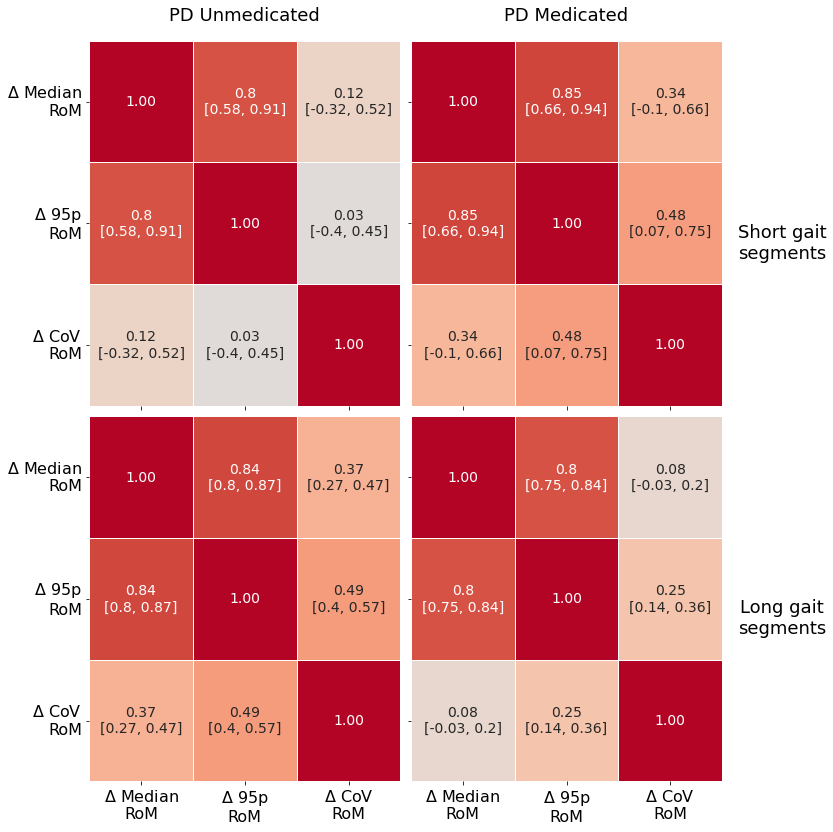

In [ ]:


static_or_dynamic = 'static'
final_week = 100

plot_vals = 'ci'  # or 'pvals'

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 12), sharex=True, sharey=True)

for i, med_status in enumerate(['no_med', 'med']):
    for j, segment_length in enumerate(segment_lengths):
        for k, side in enumerate(['mas','las']):
            delta_scores_focus = delta_scores[segment_length][f'pd_{side}_{med_status}']

            if k == 0:
                delta_median = delta_scores_focus['median'][f'{static_or_dynamic}_{final_week}']['unweighted']
                delta_95p = delta_scores_focus['95p'][f'{static_or_dynamic}_{final_week}']['unweighted']
                delta_cv = delta_scores_focus['median_cov'][f'{static_or_dynamic}_{final_week}']['unweighted']
            else:
                delta_median = np.concatenate((delta_median, delta_scores_focus['median'][f'{static_or_dynamic}_{final_week}']['unweighted']))
                delta_95p = np.concatenate((delta_95p, delta_scores_focus['95p'][f'{static_or_dynamic}_{final_week}']['unweighted']))
                delta_cv = np.concatenate((delta_cv, delta_scores_focus['median_cov'][f'{static_or_dynamic}_{final_week}']['unweighted']))

        corr_input_df = pd.DataFrame({
            '$\Delta$ Median\nRoM': delta_median,
            '$\Delta$ 95p\nRoM': delta_95p,
            '$\Delta$ CoV\nRoM': delta_cv,
        })

        corr_df = corr_input_df.corr(method='spearman')
        annot_df = corr_df.copy().astype(str)

        for row in corr_df.columns:
            for col in corr_df.columns:
                if row == col:
                    annot_df.loc[row, col] = "1.00"
                    continue

                x = corr_input_df[row]
                y = corr_input_df[col]
                valid_idx = (~x.isnull()) & (~y.isnull())
                corr, p_val = spearmanr(x[valid_idx], y[valid_idx])

                if plot_vals == 'pvals':
                    if p_val < 0.001:
                        lower_label = "(p < 0.001)"
                    elif p_val < 0.01:
                        lower_label = "(p < 0.01)"
                    elif p_val < 0.05:
                        lower_label = "(p < 0.05)"
                    else:
                        lower_label = f"(p = {np.round(p_val, 2)})"
                elif plot_vals == 'ci':
                    lower, upper = calculate_ci(x[valid_idx], corr) 
                    lower_label = f"[{np.round(lower, 2)}, {np.round(upper, 2)}]"

                annot_df.loc[row, col] = f"{np.round(corr, 2)}\n{lower_label}"

        im = sns.heatmap(
            corr_df,
            annot=annot_df,
            fmt="",
            cmap="coolwarm",
            center=0,
            linewidths=0.5,
            cbar=False,
            vmin=-1, vmax=1,
            annot_kws={"size": PLOT_TEXTSIZE},
            ax=ax[i,j]
        )

        ax[i,j].tick_params(axis='both', which='major', labelsize=PLOT_LABELSIZE)
        ax[i,j].tick_params(axis='y', rotation=0)

for j in range(2):
    ax[j, 1].yaxis.set_label_position("right")

ax[0,1].set_ylabel("Short gait\nsegments", fontsize=PLOT_TITLESIZE, labelpad=60, rotation=0)
ax[1,1].set_ylabel("Long gait\nsegments", fontsize=PLOT_TITLESIZE, labelpad=60, rotation=0)

ax[0,0].set_title('PD Unmedicated', fontsize=PLOT_TITLESIZE, pad=20)
ax[0,1].set_title('PD Medicated', fontsize=PLOT_TITLESIZE, pad=20)

plt.tight_layout()
plt.subplots_adjust(top=0.92, right=0.84)
plt.show()

if save_plots:
    fig.savefig(PATH_FIGURES / 'sr_lng_corr_measures.png', dpi=600, bbox_inches='tight')
    fig.savefig(PATH_FIGURES / 'vectors' / 'sr_lng_corr_measures.pdf', dpi=600, bbox_inches='tight')


# Plot SRM

In [ ]:
# If appropriate, load pre-computed data
base_path = Path(os.path.dirname(path_measures))

df_srm = pd.DataFrame()

for filter_type in ['unfiltered', 'filtered']:
    for signal_or_measurements in ['signal', 'measurements']:
        for method, suffix in zip(['phased', 'full'], ['l1tf_phased_', '']):
            filename = f'df_srm_{signal_or_measurements}_{suffix}preprocessed.csv'
            full_path = base_path / f'{filter_type}_gait' /  filename

            if os.path.exists(full_path):
                df_srm_subset = pd.read_csv(base_path / f'{filter_type}_gait' / filename)

                df_srm_subset['method'] = method
                df_srm_subset['filter_type'] = filter_type
                df_srm_subset['signal_or_measurements'] = signal_or_measurements

                df_srm = pd.concat([df_srm, df_srm_subset], ignore_index=True)

df_srm = df_srm.reset_index(drop=True)

df_srm = df_srm.loc[
    (
        (df_srm['method'] == 'full') &
        (df_srm['signal_or_measurements'] == 'signal')
    ) | (
        df_srm['measure'].isin(['median', '95p', 'median_cov'])
    )
]

### Static

In [19]:
focus_score_med_cols = measures + updrs_scores
focus_score_no_med_cols = measures + [x for x in updrs_scores if 'off' in x or 'total' in x]

sort_dict = {'median': 0, '95p': 1, 'median_cov': 2, f'updrs_3_{clinical_score}_off_ws': 3, f'updrs_3_{clinical_score}_on_ws': 4}

df_srm_static = df_srm.copy()

df_srm_static['med_status'] = df_srm_static['group'].apply(lambda x: 'no_med' if '_no_med' in x else 'med' if '_med' in x else 'controls')
df_srm_static['side'] = df_srm['group'].apply(lambda x: x.split('_')[1] if '_' in x else x)

df_srm_static = df_srm_static.sort_values(by=['measure', 'side'], key=lambda x: x.map(sort_dict))

measure_extended_map = {
    'median': 'Median RoM',
    '95p': r'95$^{\mathrm{th}}$ percentile RoM',
    'median_cov': 'CoV RoM',
    'updrs_1_total': 'MDS-UPDRS Part 1 total',
    'updrs_2_total': 'MDS-UPDRS Part 2 total',
    'Updrs2It12': 'MDS-UPDRS Part 2 item 12',
    'updrs_3_off_total': 'MDS-UPDRS Part 3 OFF total',
    'updrs_3_on_total': 'MDS-UPDRS Part 3 ON total',
    'Up3OfGait': 'MDS-UPDRS Part 3 OFF gait',
    'Up3OnGait': 'MDS-UPDRS Part 3 ON gait',
    'updrs_3_pro_sup_off_ws': 'MDS-UPDRS Part 3 OFF pronation-supination',
    'updrs_3_pro_sup_on_ws': 'MDS-UPDRS Part 3 ON pronation-supination',
    'updrs_3_finger_tapping_off_ws': 'MDS-UPDRS Part 3 OFF finger tapping',
    'updrs_3_finger_tapping_on_ws': 'MDS-UPDRS Part 3 ON finger tapping',
    'updrs_3_toe_tapping_off_ws': 'MDS-UPDRS Part 3 OFF toe tapping',
    'updrs_3_toe_tapping_on_ws': 'MDS-UPDRS Part 3 ON toe tapping',
    'updrs_3_leg_agility_off_ws': 'MDS-UPDRS Part 3 OFF leg agility',
    'updrs_3_leg_agility_on_ws': 'MDS-UPDRS Part 3 ON leg agility',
    'updrs_3_hand_movement_off_ws': 'MDS-UPDRS Part 3 OFF hand movement',
    'updrs_3_hand_movement_on_ws': 'MDS-UPDRS Part 3 ON hand movement',
    'updrs_3_rigidity_upper_extremity_on_ws': 'MDS-UPDRS Part 3 ON rigidity upper extremity',
    'updrs_3_rigidity_upper_extremity_off_ws': 'MDS-UPDRS Part 3 OFF rigidity upper extremity',
    'updrs_3_rigidity_lower_extremity_on_ws': 'MDS-UPDRS Part 3 ON rigidity lower extremity',
    'updrs_3_rigidity_lower_extremity_off_ws': 'MDS-UPDRS Part 3 OFF rigidity lower extremity',
}

measure_length_map = {
    'median 0_20': 'Median RoM - Short',
    'median 20_inf': 'Median RoM - Long',
    '95p 0_20': '95th percentile RoM - Short',
    '95p 20_inf': '95th percentile RoM - Long',
    'median_cov 0_20': 'CoV RoM - Short',
    'median_cov 20_inf': 'CoV RoM - Long',
}

for symptom in ['hypokinesia', 'hypokinesia_upper', 'bradykinesia', 'rigidity']:
    for med_status in ['off', 'on']:
        key = f'updrs_3_{symptom}_{med_status}_ws'
        if symptom == 'hypokinesia': 
            value = f'MDS-UPDRS Part 3 subscore {med_status.upper()}'
        else:
            value = f'MDS-UPDRS Part 3 {med_status.upper()} sum of unilateral {symptom} items'
        measure_extended_map[key] = value

df_srm_static['measure_extended'] = df_srm_static['measure'].map(measure_extended_map)

df_srm_static.loc[df_srm_static['side'] == 'mas', 'side_extended'] = 'Most affected side'
df_srm_static.loc[df_srm_static['side'] == 'las', 'side_extended'] = 'Least affected side'

#### Plot N subjects

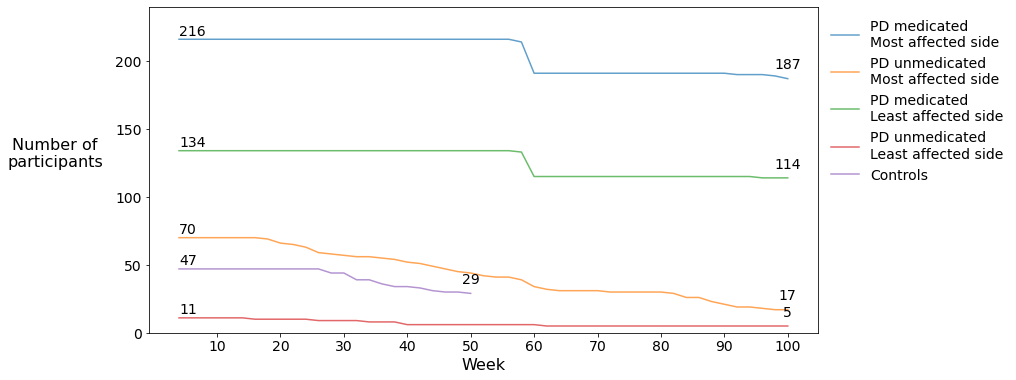

In [ ]:
group_rename = {
    'pd_mas_med': 'PD medicated\nMost affected side',
    'pd_mas_no_med': 'PD unmedicated\nMost affected side',
    'pd_las_med': 'PD medicated\nLeast affected side',
    'pd_las_no_med': 'PD unmedicated\nLeast affected side',
    'controls': 'Controls'
}

fig, ax = plt.subplots(figsize=(12,6))

signal_or_measurements = 'signal'
filter_type = 'filtered'
method = 'full'

df_static_n_subjects = df_srm_static.loc[
    (df_srm_static['signal_or_measurements'] == signal_or_measurements) &
    (df_srm_static['filter_type'] == filter_type) &
    (df_srm_static['method'] == method)
]

for group in df_static_n_subjects['group'].unique():
    df_median_group = df_static_n_subjects.loc[
        (df_static_n_subjects['group'] == group) & 
        (df_static_n_subjects['measure'] == 'median') & 
        (df_static_n_subjects['scope'].isin([f'dynamic_{x}' for x in all_weeks_2y])) &
        (df_static_n_subjects['segment_length'] == '20_inf')] 

    ax.plot(
        df_median_group['scope'], 
        df_median_group['N'], 
        label=group_rename[group], 
        linestyle='-', 
        markersize=8, 
        alpha=0.7,
    )

    ax.text(
        df_median_group['scope'].values[0], 
        df_median_group['N'].values[0] + 6, 
        f"{df_median_group['N'].values[0]}",
        fontsize=PLOT_TEXTSIZE, 
        ha='left', 
        va='center',
    )

    ax.text(
        df_median_group['scope'].values[-1], 
        df_median_group['N'].values[-1] + 5, 
        f"{df_median_group['N'].values[-1]}",
        fontsize=PLOT_TEXTSIZE,
        ha='center',
        va='bottom',
    )

tick_locs = [w / 2 for w in all_weeks_2y if w % 10 == 6]
ax.set_xticks(tick_locs)
ax.set_xticklabels(np.arange(10, 101, 10))
ax.tick_params(axis='both', labelsize=PLOT_TICKSIZE)

ax.set_ylim([0, 240])

plt.ylabel('Number of\nparticipants', fontsize=PLOT_LABELSIZE, rotation=0, labelpad=60)
plt.xlabel('Week', fontsize=PLOT_LABELSIZE)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=PLOT_LEGEND_FONTSIZE, frameon=False)
plt.show()

if save_plots:
    fig.savefig(PATH_FIGURES / 'sr_surv_curve.png', dpi=600, bbox_inches='tight')
    fig.savefig(PATH_FIGURES / 'vectors' / 'sr_surv_curve.pdf', dpi=600, bbox_inches='tight')

#### Plot 2-year SRM

C:\Users\z665206\AppData\Local\Temp\ipykernel_3356\3997866250.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_srm_dynamic['side'] = df_srm_dynamic['group'].apply(lambda x: x.split('_')[1] if '_' in x else x)
C:\Users\z665206\AppData\Local\Temp\ipykernel_3356\3997866250.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_srm_dynamic['group'] = df_srm_dynamic['group'].apply(lambda x: x.replace('_mas', '').replace('_las', ''))


PD unmedicated mas (ipcw_stab) with 70 participants at start and 17 at end.
PD medicated mas (ipcw_stab) with 216 participants at start and 187 at end.
PD medicated las (ipcw_stab) with 134 participants at start and 114 at end.
PD unmedicated mas (ipcw_stab) with 70 participants at start and 17 at end.
PD medicated mas (ipcw_stab) with 216 participants at start and 187 at end.
PD medicated las (ipcw_stab) with 134 participants at start and 114 at end.


C:\Users\z665206\AppData\Local\Temp\ipykernel_3356\3997866250.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


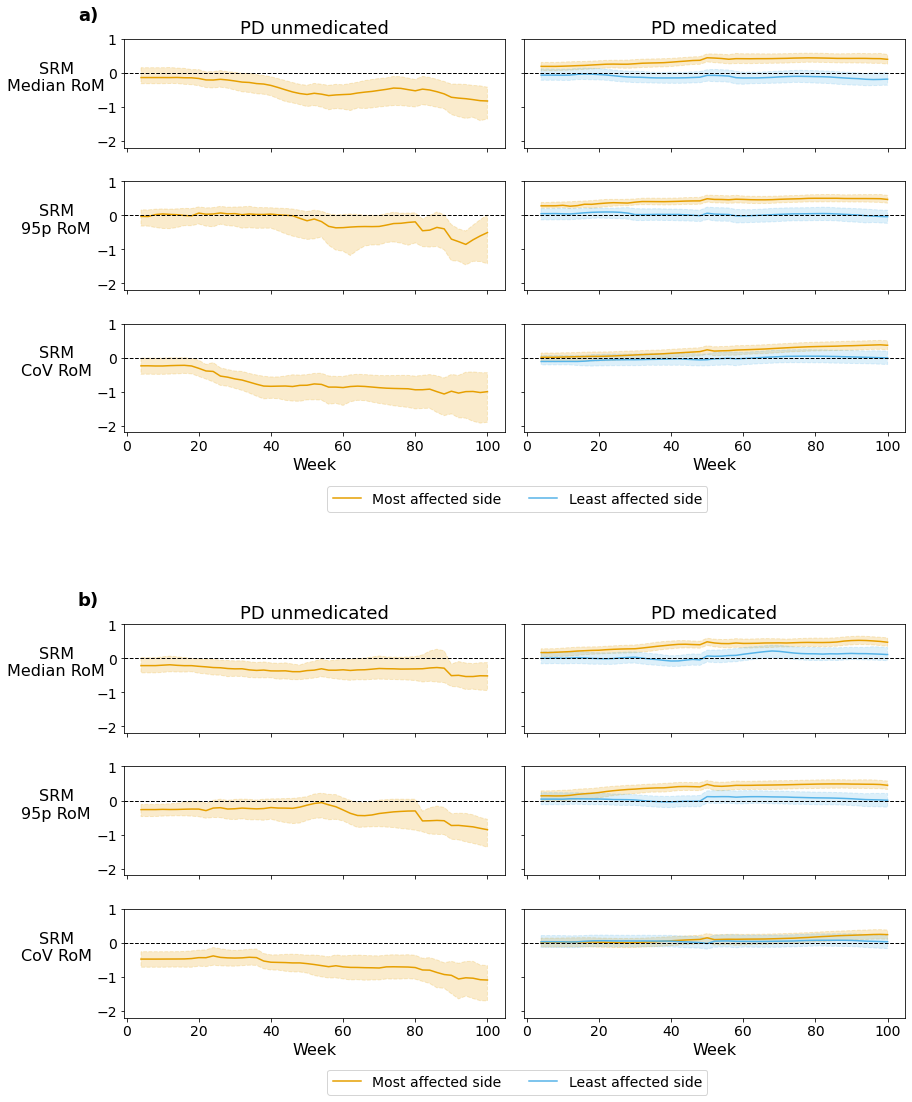

In [ ]:
rename_measures = {
    'median': 'Median RoM',
    '95p': '95p RoM',
    'median_cov': 'CoV RoM',
}

static_or_dynamic = 'dynamic'
signal_or_measurements = 'signal'
filter_type = 'filtered'
method = 'full'
updrs_score = 'updrs_3_hypokinesia_off_ws'
plot_updrs = False
weighting_type = 'ipcw_stab' # 'ipcw_raw', 'ipcw_stab', 'unweighted'
show_las_no_med = False

df_srm_dynamic = df_srm.loc[
    (df_srm['signal_or_measurements'] == signal_or_measurements) &
    (df_srm['filter_type'] == filter_type) &
    (df_srm['method'] == method)
]
df_srm_dynamic['side'] = df_srm_dynamic['group'].apply(lambda x: x.split('_')[1] if '_' in x else x)
df_srm_dynamic['group'] = df_srm_dynamic['group'].apply(lambda x: x.replace('_mas', '').replace('_las', ''))

weekly_srm = {}

nrows_total = len(measures) * 2
ncols = 2

fig = plt.figure(figsize=(14, nrows_total*3))

gs = gridspec.GridSpec(
    nrows_total + 1,  # +1 row slot for the gap
    ncols,
    height_ratios=[1, 1, 1, 1.15, 1, 1, 1],  # 0.15 is the space between (a) and (b)
    hspace=0.3,
    wspace=0.05
)

axes = []
for i in range(nrows_total):
    row_idx = i if i < 3 else i + 1  # skip the 4th grid row (the gap)
    row_axes = [fig.add_subplot(gs[row_idx, j]) for j in range(ncols)]
    axes.append(row_axes)

for k, segment_length in enumerate(segment_lengths):
    for i, measure in enumerate(measures):
        for j, group in enumerate(['pd_no_med', 'pd_med']):
            for side in ['mas', 'las']:
                if not show_las_no_med and side == 'las' and group == 'pd_no_med':
                    continue

                plot_color = COLOR_GROUP_1 if side == 'mas' else COLOR_GROUP_2

                df_focus = df_srm_dynamic.loc[
                    (df_srm_dynamic['segment_length'] == segment_length) &
                    (df_srm_dynamic['group'] == group) & 
                    (df_srm_dynamic['side'] == side) & 
                    (df_srm_dynamic['scope'].isin([f'{static_or_dynamic}_{week}' for week in final_weeks_2y] + ['1y', '2y']))
                ].copy()

                if group == 'pd_no_med' and side == 'las':
                    linestyle = '--'
                    hatchstyle = '--'
                    alpha_ci = 0.1
                else:
                    linestyle = '-'
                    hatchstyle = None
                    alpha_ci = 0.2

                if weighting_type in df_focus['weighting_type'].values:
                    df_subset = df_focus.loc[df_focus['weighting_type'] == weighting_type]
                else:
                    continue

                df_subset_measure = df_subset.loc[df_subset['measure'] == measure].copy()
                df_subset_updrs = df_subset.loc[df_subset['measure'] == updrs_score].copy()

                df_subset_updrs.loc[df_subset_updrs['scope'] == '1y', 'scope'] = 50
                df_subset_updrs.loc[df_subset_updrs['scope'] == '2y', 'scope'] = 100

                df_subset_measure['scope'] = [int(x.split('_')[1]) for x in df_subset_measure['scope']]

                min_week = df_subset_measure['scope'].min()
                max_week = df_subset_measure['scope'].max()

                n_start = df_subset_measure.loc[df_subset_measure['scope'] == min_week, 'N'].values[0]
                n_end = df_subset_measure.loc[df_subset_measure['scope'] == max_week, 'N'].values[0]

                if measure == '95p':
                    print(f"{GROUP_RENAMING[group]} {side} ({weighting_type}) with {n_start} participants at start and {n_end} at end.")

                df_subset_measure = df_subset_measure.sort_values(by='scope')

                if i == 0 and j == 1 and k == 0:
                    label = f'{AFFECTED_SIDE_RENAMING[side]}'
                else:
                    label = ''

                axes[k*3 + i][j].plot(df_subset_measure['scope'], df_subset_measure['SRM'], linestyle=linestyle, color=plot_color, label=label)

                if plot_updrs:
                    axes[k*3 + i][j].errorbar(
                        df_subset_updrs['scope'], 
                        df_subset_updrs['SRM'],
                        yerr=[df_subset_updrs['ci_upper'] - df_subset_updrs['SRM'], df_subset_updrs['SRM'] - df_subset_updrs['ci_lower']], 
                        fmt='o', 
                        color=plot_color, 
                        capsize=5 
                    )

                axes[k*3 + i][j].fill_between(df_subset_measure['scope'], df_subset_measure['ci_lower'], df_subset_measure['ci_upper'], alpha=alpha_ci, color=plot_color, linestyle='--')
        
            axes[k*3 + i][j].tick_params(axis='both', labelsize=PLOT_TICKSIZE)
            axes[k*3 + i][j].axhline(0, color='black', linestyle='--', linewidth=1)

            if i == 2:
                axes[k*3 + i][j].set_xlabel('Week', size=PLOT_LABELSIZE)
            elif i == 0:
                axes[k*3 + i][j].set_title(GROUP_RENAMING[group], size=PLOT_TITLESIZE)

            if i != 2:
                axes[k*3 + i][j].set_xticklabels([])

        axes[k*3 + i][0].set_ylabel(f'SRM\n{rename_measures[measure]}', size=PLOT_LABELSIZE, rotation=0, labelpad=40)

        if i == 0 and k == 0:
            subplot_label = 'a)'
        elif i == 0 and k == 1:
            subplot_label = 'b)'
        else:
            continue

        axes[k * 3 + i][0].text(
            -0.12, 1.3, subplot_label, fontweight='bold',
            ha='left', va='top', fontsize=PLOT_TITLESIZE,
            transform=axes[k * 3 + i][0].transAxes
        )

for (xmin, xmax) in [(0.32, 0.51), (0.32, 0.06)]:
    fig.legend(
        loc='lower left', 
        fontsize=PLOT_LEGEND_FONTSIZE, 
        frameon=True,
        ncols=2,
        bbox_to_anchor=(xmin, xmax)
    )

if signal_or_measurements == 'measurements':
    y_min = -2.8
    y_max = 1
else:
    y_min = -2.2
    y_max = 1

for k in range(len(segment_lengths)):
    for i in range(len(measures)):
        for j in range(2):
            axes[k*3 + i][j].set_ylim([y_min, y_max])

for k in range(len(segment_lengths)):
    for i in range(len(measures)):
        for j in range(2):
            axes[k*3 + i][j].set_yticks(np.arange(y_min, y_max + 0.1, 1))
            axes[k*3 + i][j].yaxis.set_major_locator(MultipleLocator(1))

            if j == 1:
                axes[k*3 + i][j].set_yticklabels([])

plt.tight_layout()
plt.show()

if save_plots and method == 'full':
    if filter_type == 'filtered' and weighting_type != 'unweighted' and signal_or_measurements == 'signal':
        prefix = 'r'
    else:
        prefix = 'sr'
    
    if signal_or_measurements == 'signal':
        filename = f'{prefix}_{weighting_type}_srm_{filter_type}_gait'
    else:
        filename = f'{prefix}_{weighting_type}_srm_{filter_type}_gait_measurements'
    
    fig.savefig(PATH_FIGURES / f'{filename}.png', dpi=600, bbox_inches='tight')
    fig.savefig(PATH_FIGURES / 'vectors' / f'{filename}.pdf', dpi=600, bbox_inches='tight')

#### Controls

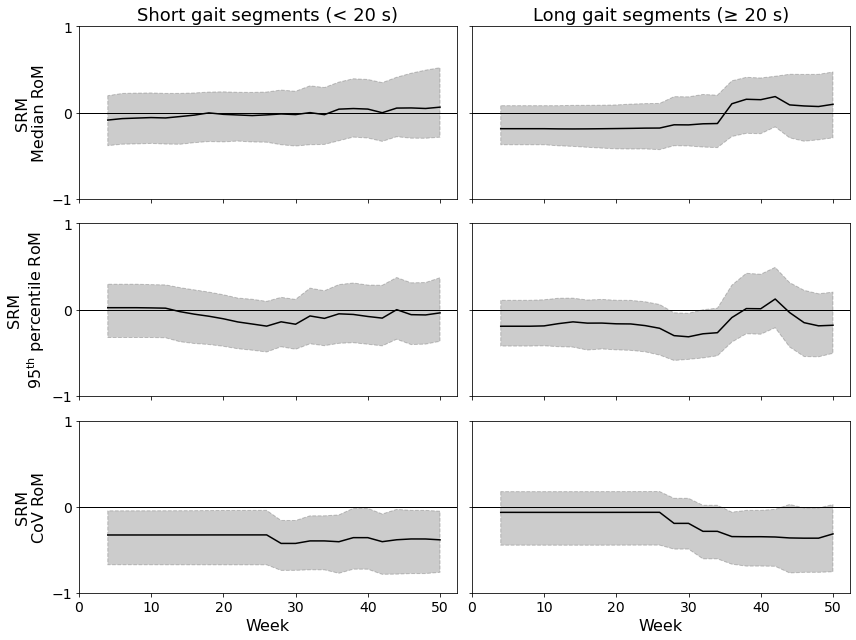

In [ ]:
static_or_dynamic = 'dynamic'
group = 'controls'

plot_color = 'black'
linestyle = '-'
hatchstyle = None
alpha_ci = 0.2

fig, ax = plt.subplots(nrows=len(measures), ncols=2, figsize=(12,len(measures) * 3), sharex=True, sharey=True)

weekly_srm = {}

for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['0_20', '20_inf']):
        
        df_focus = df_srm.loc[
            (df_srm['group'] == group) & 
            (df_srm['filter_type'] == 'filtered') &
            (df_srm['method'] == 'full') &
            (df_srm['signal_or_measurements'] == 'signal') &
            (df_srm['measure'] == measure) &
            (df_srm['segment_length'] == segment_length) &
            (df_srm['scope'].isin([f'{static_or_dynamic}_{week}' for week in final_weeks_1y]))
        ].copy()

        df_focus['scope'] = [int(x.split('_')[1]) for x in df_focus['scope']]

        min_week = df_focus['scope'].min()
        max_week = df_focus['scope'].max()

        n_start = df_focus.loc[df_focus['scope'] == min_week, 'N'].values[0]
        n_end = df_focus.loc[df_focus['scope'] == max_week, 'N'].values[0]

        # Sort by scope to ensure proper plotting
        df_focus = df_focus.sort_values(by='scope')

        ax[i,j].plot(df_focus['scope'], df_focus['SRM'], linestyle=linestyle, color=plot_color)

        ax[i,j].fill_between(df_focus['scope'], df_focus['ci_lower'], df_focus['ci_upper'], alpha=alpha_ci, color=plot_color, linestyle='--') 

        ax[i,j].tick_params(axis='both', labelsize=PLOT_TICKSIZE)
        ax[i,j].axhline(0, color=plot_color, linestyle=linestyle, linewidth=1)

        if static_or_dynamic == 'static':
            ax[i,j].set_title(SEGMENT_DURATION_RENAMING[segment_length], size=PLOT_TITLESIZE)
            ax[i,j].set_xticks([])
        elif i == 2:
            ax[i,j].set_xlabel('Week', size=PLOT_LABELSIZE)
            ax[i,j].set_xticks([0, 10, 20, 30, 40, 50])
        elif i == 0:
            if j == 0:
                ax[i,j].set_title('Short gait segments (< 20 s)', size=PLOT_TITLESIZE)
            else:
                ax[i,j].set_title('Long gait segments (≥ 20 s)', size=PLOT_TITLESIZE)

        if j == 0:
            ax[i,j].set_ylabel(f'SRM\n{measure_extended_map[measure]}', size=PLOT_LABELSIZE)
            ax[i,j].set_yticks(np.arange(-1, 1.1, 1))

        ax[i,j].set_ylim([-1, 1])

plt.tight_layout()
plt.show()

if save_plots and not l1tf_phased and filter_type == 'filtered':
    fig.savefig(PATH_FIGURES / 'sr_unweighted_srm_controls.png', dpi=600, bbox_inches='tight')
    fig.savefig(PATH_FIGURES / 'vectors' / 'sr_unweighted_srm_controls.pdf', dpi=600, bbox_inches='tight')

No data available to create placeholder for 'updrs_3_hypokinesia_on_ws'


C:\Users\z665206\AppData\Local\Temp\ipykernel_3356\722950411.py:278: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for measure, group in df_plot.groupby(['measure_length'], sort=False):
C:\Users\z665206\AppData\Local\Temp\ipykernel_3356\722950411.py:278: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for measure, group in df_plot.groupby(['measure_length'], sort=False):


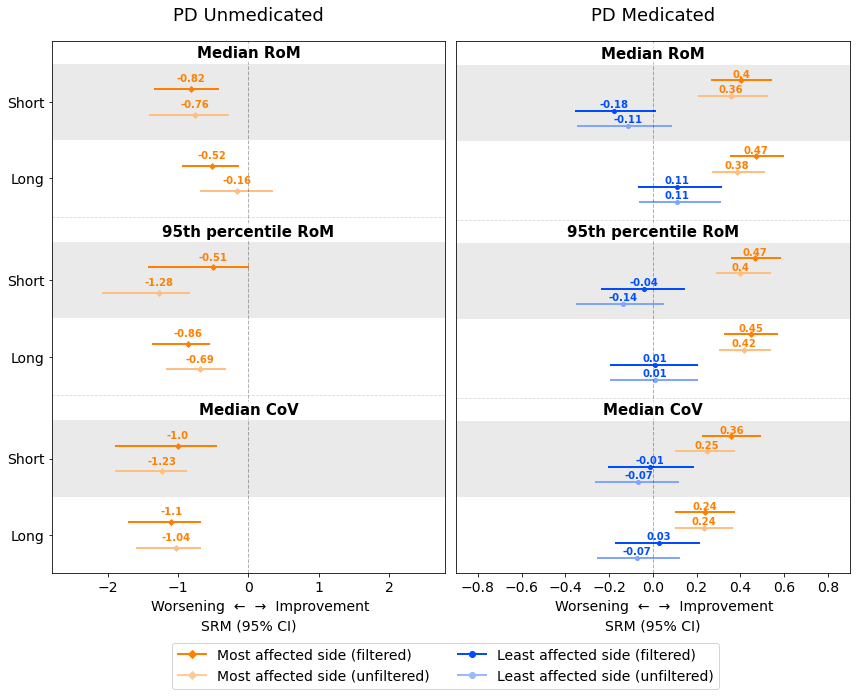

sr_comparing_filtering_2y_srm_weighted_gait


In [ ]:
static_or_dynamic = 'dynamic'
signal_or_measurements = 'signal'
scope = '2y'
show_all_sides = False

comparison_method = 'filtering'  # 'filtering' or 'weighting' or 'groups' or None

if comparison_method not in ['filtering', 'weighting', 'groups', None]:
    raise ValueError("comparison_method must be either 'filtering' or 'weighting' or 'groups'")

weighting_type = 'ipcw_stab'  # set if comparison_method == 'filtering'
filter_type = 'filtered'  # set if comparison_method == 'weighting'

band_colors = ["#BABABA", '#ffffff']  
band_width = 1

COLOR_GROUP_1 = (1.0, 0.5, 0.0)  
COLOR_GROUP_2 = (0.0, 0.3, 1.0)  

PLOT_LABELSIZE = 14
PLOT_TICKSIZE = 12

def lighten_color(color, amount=0.2):
    """Lighten a color by mixing it with white."""
    return tuple(1 - (1 - x) * (1 - amount) for x in color)

def get_color(side, status):
    base_color = COLOR_GROUP_1 if side == 'mas' else (COLOR_GROUP_2 if side == 'las' else COLOR_GROUP_NEUTRAL)
    return base_color if status in ['Filtered', 'Weighted', 'controls', 'none'] else lighten_color(base_color, 0.5)

band_idx = 1

if scope == '1y':
    final_week = 50
    method = 'phased'
else:
    final_week = 100
    method = 'full'

if comparison_method in ['filtering', 'weighting', 'groups']:
    nrows = 1
    height = 9
    scopes = [scope]
    df_srm_focus = df_srm_static.loc[
        (
            (df_srm_static['method'] == method) |
            (df_srm_static['group'] == 'controls')
        ) &
        (
            (df_srm_static['signal_or_measurements'] == signal_or_measurements) &
            (df_srm_static['scope'] == f'{static_or_dynamic}_{final_week}')
            ) | (
                (df_srm_static['scope'] == scope)
            )
    ].copy()
else:
    nrows = 2
    height = 14
    scopes = ['1y', '2y']
    df_srm_focus = df_srm_static.loc[
        (df_srm_static['signal_or_measurements'] == signal_or_measurements) | (df_srm_static['scope'].isin(scopes))
    ].copy()

df_srm_focus = df_srm_focus.loc[df_srm_focus['weighting_type'] != 'ipcw_raw'].reset_index(drop=True)

if comparison_method == 'groups':
    ncols = 1
    med_states = ['no_med']
else:
    ncols = 2
    med_states = ['no_med', 'med']

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, height), sharex=False, sharey=False)

df_srm_focus['filter_status'] = df_srm_focus['filter_type'].map({
    'filtered': 'Filtered',
    'unfiltered': 'Unfiltered'
})

df_srm_focus['weighting_status'] = df_srm_focus['weighting_type'].map({
    'ipcw_stab': 'Weighted',
    'unweighted': 'Unweighted'
})

if comparison_method == 'filtering':
    df_srm_focus = df_srm_focus.loc[df_srm_focus['weighting_type'] == weighting_type]
    focus_variable = 'filter_status'
    focus_variable_values = ['Filtered', 'Unfiltered']
    default_value = 'Filtered'
elif comparison_method == 'weighting':
    df_srm_focus = df_srm_focus.loc[df_srm_focus['filter_type'] == filter_type]
    focus_variable = 'weighting_status'
    focus_variable_values = ['Weighted', 'Unweighted']
    default_value = 'Weighted'
else:
    df_srm_focus = df_srm_focus.loc[
        (df_srm_focus['filter_type'] == 'filtered') & 
        (
            (df_srm_focus['weighting_type'] == 'ipcw_stab') |
            (df_srm_focus['group'] == 'controls')
        )
    ]
    focus_variable = 'group'
    focus_variable_values = ['pd_mas_med', 'pd_las_med', 'pd_mas_no_med', 'pd_las_no_med', 'controls']
    default_value = 'controls'

for i, scope in enumerate(scopes):
    if comparison_method is None:
        if scope == '1y':
            final_week = 50
            method = 'phased'
        else:
            final_week = 100
            method = 'full'

        df_srm_focus_scope = df_srm_focus.loc[
            (df_srm_focus['scope'] == scope) |
            (
                (df_srm_focus['signal_or_measurements'] == signal_or_measurements) &
                (df_srm_focus['scope'] == f'{static_or_dynamic}_{final_week}')
            ) & 
            (
                (df_srm_focus['method'] == method) |
                (df_srm_focus['group'] == 'controls')
            )
        ].copy()
    else:
        df_srm_focus_scope = df_srm_focus.copy()

    for j, med_state in enumerate(med_states):
        if not show_all_sides and med_state == 'no_med':
            df_srm_focus_scope = df_srm_focus_scope.loc[~((df_srm_focus_scope['side'] == 'las') & (df_srm_focus_scope['med_status'] == 'no_med'))].reset_index(drop=True)

        # Add measure type
        df_srm_focus_scope['measure_type'] = df_srm_focus_scope['scope'].apply(
            lambda s: 'clinical' if s in ['1y', '2y'] else 'digital'
        )

        # Segment length renaming
        df_srm_focus_scope['segment_length_trunc'] = df_srm_focus_scope['segment_length'].apply(lambda x: SEGMENT_DURATION_RENAMING[x])
        df_srm_focus_scope = df_srm_focus_scope.loc[
            ~((df_srm_focus_scope['segment_length_trunc'] == 'short') & (df_srm_focus_scope['measure_type'] == 'clinical'))
        ].reset_index(drop=True)
        df_srm_focus_scope.loc[
            (df_srm_focus_scope['segment_length_trunc'] == 'long') & (df_srm_focus_scope['measure_type'] == 'clinical'),
            'segment_length_trunc'
        ] = ''

        # Measure length
        df_srm_focus_scope['measure_length'] = df_srm_focus_scope.apply(
            lambda x: x['measure'] if x['measure_type'] == 'clinical' else f"{x['measure']} {x['segment_length']}", axis=1
        )
        df_srm_focus_scope['measure_length_extended'] = df_srm_focus_scope.apply(
            lambda x: measure_length_map.get(x['measure_length'], x['measure_extended']),
            axis=1
        )

        # Subset to med_state and measures of interest
        if comparison_method == 'groups':
            df_srm_med_state = df_srm_focus_scope.loc[
                (
                    (df_srm_focus_scope['med_status'] == med_state) |
                    (df_srm_focus_scope['group'] == 'controls') 
                ) &
                (df_srm_focus_scope['measure'].isin([x for x in focus_score_med_cols if 'hypokinesia' in x or x in measures]))
            ].sort_values(by=['measure', 'side_extended', focus_variable]).reset_index(drop=True)
        else:
            df_srm_med_state = df_srm_focus_scope.loc[
                (df_srm_focus_scope['med_status'] == med_state) & 
                (df_srm_focus_scope['measure'].isin([x for x in focus_score_med_cols if 'hypokinesia' in x or x in measures]))
            ].sort_values(by=['measure', 'side_extended', focus_variable]).reset_index(drop=True)

        if comparison_method in ['filtering', 'weighting']:
            axis = ax[j]
        elif comparison_method == 'groups':
            axis = ax
        else:
            axis = ax[i,j]

        # Flip SRMs for clinical measures
        mask = df_srm_med_state['measure_type'] == 'clinical'
        df_srm_med_state.loc[mask, 'SRM'] *= -1
        df_srm_med_state.loc[mask, ['ci_lower', 'ci_upper']] = -df_srm_med_state.loc[mask, ['ci_upper', 'ci_lower']].values

        # In case of filtering, only keep on line per clinical measure (filtered / unfiltered are identical for clinical measures)
        if comparison_method == 'filtering':
            df_clinical = df_srm_med_state[df_srm_med_state['measure_type'] == 'clinical'].drop_duplicates(
                subset=['measure', 'side_extended'], keep='first'
            )
        else:
            df_clinical = df_srm_med_state[df_srm_med_state['measure_type'] == 'clinical']

        df_digital = df_srm_med_state[df_srm_med_state['measure_type'] == 'digital']

        df_plot = pd.concat([df_clinical, df_digital], ignore_index=True)

        if comparison_method in ['filtering', 'weighting']:
            df_plot['color'] = df_plot.apply(
                lambda r: get_color(r['side'], r.get(focus_variable, default_value)), axis=1
            )
        else:
            df_plot['color'] = df_plot.apply(
                lambda r: get_color(r['side'], 'controls'), axis=1
            )            
            
        y_positions = []
        current_y = 0

        if med_state == 'med':
            within_offset = 1            # small gap between filtered and unfiltered, weighted unweighted
            side_offset = 1              # slightly larger gap between MAS and LAS
            between_measure = 3.7        # gap between measures
            between_measure_length = 2   # gap between measure lengths (e.g., median 0_20 and median 20_inf)
            header_add_y = 1.75
            header_hline_offset_low = 1.1
            header_hline_offset_high = 2.5
        else:
            within_offset = 1
            side_offset = 0.5
            between_measure = 3
            between_measure_length = 2
            header_add_y = 1.4
            header_hline_offset_low = 1
            header_hline_offset_high = 2

        if comparison_method == 'weighting' or comparison_method is None:
            measure_order = ['median 0_20', 'median 20_inf', '95p 0_20', '95p 20_inf', 'median_cov 0_20', 'median_cov 20_inf', 'updrs_3_hypokinesia_off_ws', 'updrs_3_hypokinesia_on_ws'][::-1]
        else:
            measure_order = ['median 0_20', 'median 20_inf', '95p 0_20', '95p 20_inf', 'median_cov 0_20', 'median_cov 20_inf'][::-1]

        df_plot['skip_plot'] = False
        if med_state == 'no_med' and 'updrs_3_hypokinesia_on_ws' not in df_plot['measure_length'].values:
            for z, weighted_bool in enumerate([True, False]):
                extra_row = df_plot.loc[
                    (df_plot['measure'] == 'updrs_3_hypokinesia_off_ws') &
                    (df_plot['group'] == 'pd_mas_no_med') &
                    (df_plot['segment_length'] == '0_20') &
                    (df_plot['weighting_type'] == ('ipcw_stab' if weighted_bool else 'unweighted'))
                ].copy()
                
                if extra_row.empty:
                    print("No data available to create placeholder for 'updrs_3_hypokinesia_on_ws'")
                    continue

                extra_row['measure'] = 'updrs_3_hypokinesia_on_ws'
                extra_row['measure_length'] = 'updrs_3_hypokinesia_on_ws'
                extra_row['measure_length_extended'] = measure_extended_map['updrs_3_hypokinesia_on_ws']
                extra_row['skip_plot'] = True
                
                df_plot = pd.concat([df_plot, extra_row], ignore_index=True)
                current_y += 1  
            
        df_plot = df_plot[df_plot['measure_length'].isin(measure_order)]
        df_plot['measure_length'] = pd.Categorical(
            df_plot['measure_length'],
            categories=measure_order,
            ordered=True
        )

        side_order = ['mas', 'las', 'controls'][::-1]
        df_plot['side'] = pd.Categorical(df_plot['side'], categories=side_order, ordered=True)

        df_plot[focus_variable] = pd.Categorical(
            df_plot[focus_variable],
            categories=focus_variable_values[::-1],
            ordered=True
        )

        df_plot = df_plot.sort_values(
            by=['measure_length', 'side', focus_variable]
        ).reset_index(drop=True)

        for measure, group in df_plot.groupby(['measure_length'], sort=False):
            for side in side_order:
                side_group = group[group['side'] == side]
                for status in focus_variable_values:
                    row_idx = side_group[side_group[focus_variable] == status].index
                    if len(row_idx) == 0:
                        continue

                    y_positions.extend([current_y] * len(row_idx))

                    if status == default_value:
                        current_y += within_offset
                    else:
                        current_y += side_offset
                        
            if '20_inf' in measure[0]:
                current_y += between_measure_length - side_offset
            else:
                current_y += between_measure - side_offset

        df_plot['y_pos'] = y_positions

        tick_positions = []
        tick_labels = []

        for measure, group in df_plot.groupby('measure_length_extended', sort=False):
            y_middle = group['y_pos'].mean()  
            tick_positions.append(y_middle)

            if 'Short' in measure and 'UPDRS' not in measure:
                measure_label = 'Short'
            elif 'UPDRS' not in measure:
                measure_label = 'Long'
            else:
                measure_label = ''

            tick_labels.append(measure_label)

        for measure, group in df_plot.groupby('measure_length_extended', sort=False):
            y_min = group['y_pos'].min() - band_width
            y_max = group['y_pos'].max() + band_width
            axis.axhspan(y_min, y_max, facecolor=band_colors[band_idx % len(band_colors)], alpha=0.3, zorder=0)
            band_idx += 1

        df_plot['side'] = pd.Categorical(df_plot['side'], categories=side_order, ordered=True)

        for _, row in df_plot.iterrows():
            if row.get('skip_plot', False):
                continue

            if row['side'] == 'mas':
                marker = 'D'
            elif row['side'] == 'las':
                marker = 'o'
            else:
                marker = 's'
            
            axis.hlines(
                y=row['y_pos'], xmin=row['ci_lower'], xmax=row['ci_upper'],
                color=row['color'], linewidth=2
            )
            axis.plot(row['SRM'], row['y_pos'], marker=marker, color=row['color'], markersize=4)

            text_color = get_color(row['side'], 'Filtered')

            axis.text(
                row['SRM'], row['y_pos'] + 0.4,
                f"{np.round(row['SRM'], 2)}" if np.round(row['SRM'], 2) != -0.00 else 0.00, ha='center', va='center', fontsize=10, color=text_color, weight='bold'
            )
        if med_state == 'no_med':
            axis.set_xlim([-2.8, 2.8])
        else:
            axis.set_xlim([-0.9, 0.9])


        if i == 1 and comparison_method is None:
            y_offset = -0.06
        elif i == 0 and comparison_method is None:
            axis.set_xticks([])
            axis.set_xticklabels([])
        else:
            y_offset = -0.05

        if i != 0 or comparison_method is not None:
            axis.set_xlabel("SRM (95% CI)", fontsize=PLOT_LABELSIZE, labelpad=25)

        axis.text(
            0.53, y_offset, "Worsening  ←  →  Improvement",
            ha='center', va='top', fontsize=PLOT_TEXTSIZE,
            transform=axis.transAxes
        )

        axis.axvline(x=0, linestyle='--', color='black', alpha=0.3, linewidth=1)
        
        if comparison_method in [None, 'weighting']:
            tick_positions = tick_positions[2:]
            tick_labels = tick_labels[2:]

        if j == 0:
            axis.set_yticks(tick_positions)
            axis.set_yticklabels(tick_labels, fontsize=PLOT_LABELSIZE)
        else:
            axis.set_yticks([])
            axis.set_yticklabels([])

        axis.tick_params(axis='x', labelsize=PLOT_LABELSIZE)

        df_plot['measure_root'] = df_plot['measure_length'].str.split().str[0]

        for measure_root, group in df_plot.groupby('measure_root', sort=False):
            if med_state == 'no_med' and comparison_method in ['weighting', None] and measure_root == 'updrs_3_hypokinesia_on_ws':
                continue
            
            y_min = group['y_pos'].min()
            y_max = group['y_pos'].max()
            y_top = y_max + header_add_y
            x_label_pos = axis.get_xlim()[0] + (axis.get_xlim()[1] - axis.get_xlim()[0]) / 2 

            if measure_root == 'median':
                label = 'Median RoM'
            elif measure_root == '95p':
                label = '95th percentile RoM'
            elif measure_root == 'median_cov':
                label = 'Median CoV'
            elif measure_root == 'updrs_3_hypokinesia_off_ws':
                label = measure_extended_map['updrs_3_hypokinesia_off_ws']
            elif measure_root == 'updrs_3_hypokinesia_on_ws':
                label = measure_extended_map['updrs_3_hypokinesia_on_ws']
            else:
                label = measure_root

            axis.text(
                x=x_label_pos,
                y=y_top,
                s=label,
                fontsize=PLOT_LABELSIZE + 1,
                fontweight='bold',
                ha='center',
                va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.1'),
                transform=axis.transData,
                zorder=10
            )

            if measure_root == 'updrs_3_hypokinesia_on_ws':
                axis.axhline(y=y_max + header_hline_offset_low, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

            if measure_root not in ['median', 'updrs_3_hypokinesia_on_ws']:
                axis.axhline(y=y_max + header_hline_offset_high, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

            y_min_all = df_plot['y_pos'].min() - 1
            if med_state == 'med':
                y_max_all = df_plot['y_pos'].max() + 2.6
            else:
                y_max_all = df_plot['y_pos'].max() + 1.9
            axis.set_ylim(y_min_all, y_max_all)

        if comparison_method is None and j == 1:
            axis.yaxis.set_label_position("right")
            if i == 0:
                axis.set_ylabel("One-year\nSRM", fontsize=PLOT_TITLESIZE, labelpad=60, rotation=0)
            else:
                axis.set_ylabel("Two-year\nSRM", fontsize=PLOT_TITLESIZE, labelpad=60, rotation=0)

        if comparison_method != 'groups':
            if i == 1:
                continue

            if j == 0:
                axis.set_title('PD Unmedicated', fontsize=PLOT_TITLESIZE, pad=20)
            else:
                axis.set_title('PD Medicated', fontsize=PLOT_TITLESIZE, pad=20)

mas_1 = COLOR_GROUP_1
mas_2 = lighten_color(COLOR_GROUP_1, 0.6)
las_1 = COLOR_GROUP_2
las_2 = lighten_color(COLOR_GROUP_2, 0.6)

if comparison_method == 'weighting':
    legend_elements = [
        Line2D([0], [0], color=mas_1, lw=2, marker='D',
            label='Most affected side (weighted)'),
        Line2D([0], [0], color=mas_2, lw=2, marker='D',
            label='Most affected side (unweighted)'),
        Line2D([0], [0], color=las_1, lw=2, marker='o',
            label='Least affected side (weighted)'),
        Line2D([0], [0], color=las_2, lw=2, marker='o',
            label='Least affected side (unweighted)'),
    ]
elif comparison_method == 'filtering':
    legend_elements = [
        Line2D([0], [0], color=mas_1, lw=2, marker='D',
            label='Most affected side (filtered)'),
        Line2D([0], [0], color=mas_2, lw=2, marker='D',
            label='Most affected side (unfiltered)'),
        Line2D([0], [0], color=las_1, lw=2, marker='o',
            label='Least affected side (filtered)'),
        Line2D([0], [0], color=las_2, lw=2, marker='o',
            label='Least affected side (unfiltered)'),
    ]
elif comparison_method == 'groups':
    legend_elements = [
        Line2D([0], [0], color=mas_1, lw=2, marker='D',
            label='Most affected side'),
        Line2D([0], [0], color=COLOR_GROUP_NEUTRAL, lw=2, marker='s',
            label='Controls'),
    ]
else:
    legend_elements = [
        Line2D([0], [0], color=mas_1, lw=2, marker='D',
            label='Most affected side'),
        Line2D([0], [0], color=las_1, lw=2, marker='o',
            label='Least affected side')
    ]

if comparison_method == 'groups':
    y_dispos = -0.06
    x_dispos = 0.56
    ncols = 3
elif comparison_method == 'filtering':
    y_dispos = -0.08
    x_dispos = 0.52
    ncols = 2
elif comparison_method == 'weighting':
    y_dispos = -0.08
    x_dispos = 0.52
    ncols = 2
else:
    y_dispos = -0.03
    x_dispos = 0.52
    ncols = 2

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=ncols,
    fontsize=PLOT_LEGEND_FONTSIZE,
    frameon=True,
    bbox_to_anchor=(x_dispos, y_dispos),
)

plt.tight_layout()
# plt.subplots_adjust(top=0.92)
plt.show()

if save_plots:
    if comparison_method == 'weighting':
        filename_detail = filter_type
    elif comparison_method == 'filtering':
        filename_detail = 'weighted' if weighting_type != 'unweighted' else 'unweighted'
    elif comparison_method == 'groups':
        filename_detail = 'groups'
    else:
        filename_detail = f'weighted_{filter_type}' if weighting_type != 'unweighted' else f'unweighted_{filter_type}'

    if comparison_method is None:
        filename = f'r_srm_{filename_detail}'
    else:
        filename = f'sr_comparing_{comparison_method}_{scope}_srm_{filename_detail}_gait'

    fig.savefig(PATH_FIGURES / f'{filename}.png', dpi=600, bbox_inches='tight')
    fig.savefig(PATH_FIGURES / 'vectors' / f'{filename}.pdf', dpi=600, bbox_inches='tight')